In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

DATA_DIR = Path(r"C:\Users\aduak\Downloads\capstone")
CLEAN_DIR = DATA_DIR / "cleaned"

sait_valid = pd.read_csv(
    CLEAN_DIR / "sait_hourly_valid.csv",
    parse_dates=["timestamp"]
)

print("SAIT valid shape:", sait_valid.shape)
print(
    "Date range:",
    sait_valid["timestamp"].min(),
    "to",
    sait_valid["timestamp"].max()
)

display(sait_valid.head())

SAIT valid shape: (13423, 12)
Date range: 2019-03-08 20:00:00 to 2023-09-19 08:00:00


,timestamp,carport_hourly_wh,carport_observations,rooftop_hourly_wh,rooftop_observations,total_hourly_wh,total_observations,quality_flag,year,month,day,hour
0,2019-03-08 20:00:00,0.0,60,3.233333,60,3.233333,60,complete,2019,3,8,20
1,2019-03-08 21:00:00,0.0,60,3.716667,60,3.716667,60,complete,2019,3,8,21
2,2019-03-08 22:00:00,0.0,60,3.483333,60,3.483333,60,complete,2019,3,8,22
3,2019-03-08 23:00:00,0.0,60,3.533333,60,3.533333,60,complete,2019,3,8,23
4,2019-03-09 00:00:00,0.0,60,3.216667,60,3.216667,60,complete,2019,3,9,0


In [2]:
sait_validation_periods = (
    sait_valid
    .assign(year=sait_valid["timestamp"].dt.year)
    .groupby("year")
    .agg(
        valid_hours=("timestamp", "size"),
        first_valid=("timestamp", "min"),
        last_valid=("timestamp", "max"),
        mean_generation=("total_hourly_wh", "mean")
    )
    .reset_index()
)

display(sait_validation_periods)

,year,valid_hours,first_valid,last_valid,mean_generation
0,2019,1650,2019-03-08 20:00:00,2019-09-29 16:00:00,3986.505465
1,2020,3256,2020-01-10 13:00:00,2020-12-01 23:00:00,2636.895867
2,2021,928,2021-02-18 09:00:00,2021-06-29 14:00:00,3323.186692
3,2022,1426,2022-11-02 14:00:00,2022-12-31 23:00:00,972.641450
4,2023,6163,2023-01-01 00:00:00,2023-09-19 08:00:00,3390.505847


In [3]:
sait_2023 = sait_valid[
    sait_valid["timestamp"].dt.year == 2023
].copy()

print("2023 valid SAIT hours:", len(sait_2023))
print(
    sait_2023["timestamp"].min(),
    "to",
    sait_2023["timestamp"].max()
)

2023 valid SAIT hours: 6163
2023-01-01 00:00:00 to 2023-09-19 08:00:00


## SAIT Validation Limitation

The current CWEEDS Calgary dataset covers 1998–2017, while the SAIT campus solar-generation dataset begins in 2018. Therefore, there is no direct temporal overlap between the available Calgary CWEEDS observations and SAIT measurements.

A timestamp-aligned real-world validation cannot be completed with the currently available weather file.

The validation pipeline is therefore prepared using the cleaned SAIT hourly dataset, with 2023 selected as the preferred validation period because it contains the largest number of complete hourly PV observations.

Once Calgary weather data covering 2023 is obtained, it can be processed using the same cleaning and feature-engineering pipeline as the historical CWEEDS data and passed through the trained Random Forest model for timestamp-level comparison against SAIT measurements.

In [4]:
def prepare_model_features(df):
    df = df.copy()

    df["year"] = df["timestamp"].dt.year
    df["day_of_year"] = df["timestamp"].dt.dayofyear
    df["hour"] = df["timestamp"].dt.hour

    df["hour_sin"] = np.sin(
        2 * np.pi * df["hour"] / 24
    )

    df["hour_cos"] = np.cos(
        2 * np.pi * df["hour"] / 24
    )

    df["doy_sin"] = np.sin(
        2 * np.pi * df["day_of_year"] / 365.25
    )

    df["doy_cos"] = np.cos(
        2 * np.pi * df["day_of_year"] / 365.25
    )

    return df

In [5]:
required_features = [
    "latitude",
    "longitude",
    "elevation_m",
    "dry_bulb_temp_c",
    "dew_point_temp_c",
    "wind_speed_ms",
    "station_pressure_pa",
    "hour_sin",
    "hour_cos",
    "doy_sin",
    "doy_cos",
    "city_Calgary",
    "city_Edmonton",
    "city_Lethbridge",
    "city_Medicine Hat"
]

print("Required model features:")
for feature in required_features:
    print("-", feature)

Required model features:
- latitude
- longitude
- elevation_m
- dry_bulb_temp_c
- dew_point_temp_c
- wind_speed_ms
- station_pressure_pa
- hour_sin
- hour_cos
- doy_sin
- doy_cos
- city_Calgary
- city_Edmonton
- city_Lethbridge
- city_Medicine Hat


In [6]:
def add_city_dummies_for_calgary(df):
    df = df.copy()

    df["city_Calgary"] = 1
    df["city_Edmonton"] = 0
    df["city_Lethbridge"] = 0
    df["city_Medicine Hat"] = 0

    return df

In [7]:
def merge_with_sait_predictions(weather_df, sait_df):
    weather_df = weather_df.copy()
    sait_df = sait_df.copy()

    merged = pd.merge(
        weather_df,
        sait_df[
            [
                "timestamp",
                "carport_hourly_wh",
                "rooftop_hourly_wh",
                "total_hourly_wh"
            ]
        ],
        on="timestamp",
        how="inner"
    )

    return merged

In [8]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

def evaluate_predictions(actual, predicted):
    return {
        "R2": r2_score(actual, predicted),
        "MAE": mean_absolute_error(actual, predicted),
        "RMSE": np.sqrt(
            mean_squared_error(actual, predicted)
        )
    }

In [9]:
VALIDATION_DIR = DATA_DIR / "validation"
VALIDATION_DIR.mkdir(exist_ok=True)

sait_validation_periods.to_csv(
    VALIDATION_DIR / "sait_validation_periods.csv",
    index=False
)

sait_2023.to_csv(
    VALIDATION_DIR / "sait_2023_valid_hours.csv",
    index=False
)

print("Validation preparation files saved.")

Validation preparation files saved.


In [10]:
cweeds = pd.read_csv(
    CLEAN_DIR / "clean_cweeds_4cities.csv",
    parse_dates=["timestamp"],
    low_memory=False
)

calgary_weather = cweeds[
    cweeds["city"] == "Calgary"
].copy()

print(
    "Calgary CWEEDS:",
    calgary_weather["timestamp"].min(),
    "to",
    calgary_weather["timestamp"].max()
)

print(
    "SAIT:",
    sait_valid["timestamp"].min(),
    "to",
    sait_valid["timestamp"].max()
)

Calgary CWEEDS: 1998-01-01 00:00:00 to 2017-12-31 23:00:00
SAIT: 2019-03-08 20:00:00 to 2023-09-19 08:00:00


In [11]:
overlap_start = max(
    calgary_weather["timestamp"].min(),
    sait_valid["timestamp"].min()
)

overlap_end = min(
    calgary_weather["timestamp"].max(),
    sait_valid["timestamp"].max()
)

print("Overlap start:", overlap_start)
print("Overlap end:", overlap_end)

if overlap_start <= overlap_end:
    print("Temporal overlap exists.")
else:
    print("NO temporal overlap exists.")

Overlap start: 2019-03-08 20:00:00
Overlap end: 2017-12-31 23:00:00
NO temporal overlap exists.


In [12]:
weather_requirements = pd.DataFrame({
    "Variable": [
        "timestamp",
        "latitude",
        "longitude",
        "elevation_m",
        "dry_bulb_temp_c",
        "dew_point_temp_c",
        "wind_speed_ms",
        "station_pressure_pa"
    ],
    "Required": [True] * 8,
    "Purpose": [
        "SAIT alignment and time features",
        "GHI model geographic input",
        "GHI model geographic input",
        "GHI model geographic input",
        "GHI model weather input",
        "GHI model weather input",
        "GHI model weather input",
        "GHI model weather input"
    ]
})

display(weather_requirements)

,Variable,Required,Purpose
0,timestamp,True,SAIT alignment and time features
1,latitude,True,GHI model geographic input
2,longitude,True,GHI model geographic input
3,elevation_m,True,GHI model geographic input
4,dry_bulb_temp_c,True,GHI model weather input
5,dew_point_temp_c,True,GHI model weather input
6,wind_speed_ms,True,GHI model weather input
7,station_pressure_pa,True,GHI model weather input


In [13]:
weather_requirements.to_csv(
    VALIDATION_DIR / "calgary_weather_requirements_for_sait_validation.csv",
    index=False
)

In [14]:
# ============================================================
# D6 - TEMPORAL OVERLAP AUDIT
# ============================================================

cweeds = pd.read_csv(
    CLEAN_DIR / "clean_cweeds_4cities.csv",
    parse_dates=["timestamp"],
    low_memory=False
)

calgary_cweeds = (
    cweeds[cweeds["city"] == "Calgary"]
    .copy()
)

coverage_summary = pd.DataFrame({
    "Dataset": ["Calgary CWEEDS", "SAIT Valid Solar"],
    "Start": [
        calgary_cweeds["timestamp"].min(),
        sait_valid["timestamp"].min()
    ],
    "End": [
        calgary_cweeds["timestamp"].max(),
        sait_valid["timestamp"].max()
    ],
    "Rows": [
        len(calgary_cweeds),
        len(sait_valid)
    ]
})

display(coverage_summary)

overlap_start = max(
    calgary_cweeds["timestamp"].min(),
    sait_valid["timestamp"].min()
)

overlap_end = min(
    calgary_cweeds["timestamp"].max(),
    sait_valid["timestamp"].max()
)

has_overlap = overlap_start <= overlap_end

print("Temporal overlap exists:", has_overlap)

,Dataset,Start,End,Rows
0,Calgary CWEEDS,1998-01-01 00:00:00,2017-12-31 23:00:00,175320
1,SAIT Valid Solar,2019-03-08 20:00:00,2023-09-19 08:00:00,13423


Temporal overlap exists: False


In [15]:
d6_status = pd.DataFrame({
    "Deliverable": [
        "D6 - SAIT Campus Real-World Validation"
    ],
    "Required_Method": [
        "Timestamp-aligned Calgary weather prediction vs measured SAIT PV output"
    ],
    "Status": [
        "Blocked by supplied source-data coverage"
    ],
    "Reason": [
        "Calgary CWEEDS supplied for analysis ends 2017-12-31, while usable SAIT solar observations begin in 2019."
    ],
    "Action_Taken": [
        "Prepared validation pipeline and performed historical-climatology vs SAIT profile consistency check."
    ]
})

display(d6_status)

,Deliverable,Required_Method,Status,Reason,Action_Taken
0,D6 - SAIT Campus Real-World Validation,Timestamp-aligned Calgary weather prediction v...,Blocked by supplied source-data coverage,Calgary CWEEDS supplied for analysis ends 2017...,Prepared validation pipeline and performed his...


In [16]:
# ============================================================
# HISTORICAL CALGARY SOLAR CLIMATOLOGY
# ============================================================

calgary_cweeds["month"] = (
    calgary_cweeds["timestamp"].dt.month
)

calgary_cweeds["hour"] = (
    calgary_cweeds["timestamp"].dt.hour
)

calgary_climatology = (
    calgary_cweeds
    .groupby(["month", "hour"])
    .agg(
        historical_mean_ghi=(
            "ghi_wh_m2",
            "mean"
        )
    )
    .reset_index()
)

display(calgary_climatology.head())

,month,hour,historical_mean_ghi
0,1,0,0.0
1,1,1,0.0
2,1,2,0.0
3,1,3,0.0
4,1,4,0.0


In [17]:
sait_profile = (
    sait_valid
    .groupby(["month", "hour"])
    .agg(
        measured_mean_pv=(
            "total_hourly_wh",
            "mean"
        ),
        valid_hours=(
            "timestamp",
            "size"
        )
    )
    .reset_index()
)

display(sait_profile.head())

,month,hour,measured_mean_pv,valid_hours
0,1,0,21.669231,52
1,1,1,21.647436,52
2,1,2,21.785897,52
3,1,3,21.855128,52
4,1,4,21.656731,52


In [18]:
profile_comparison = pd.merge(
    calgary_climatology,
    sait_profile,
    on=["month", "hour"],
    how="inner"
)

print("Comparable month-hour combinations:",
      len(profile_comparison))

display(profile_comparison.head())

Comparable month-hour combinations: 288


,month,hour,historical_mean_ghi,measured_mean_pv,valid_hours
0,1,0,0.0,21.669231,52
1,1,1,0.0,21.647436,52
2,1,2,0.0,21.785897,52
3,1,3,0.0,21.855128,52
4,1,4,0.0,21.656731,52


In [19]:
profile_comparison["ghi_normalized"] = (
    profile_comparison["historical_mean_ghi"]
    /
    profile_comparison["historical_mean_ghi"].max()
)

profile_comparison["pv_normalized"] = (
    profile_comparison["measured_mean_pv"]
    /
    profile_comparison["measured_mean_pv"].max()
)

In [20]:
profile_correlation = (
    profile_comparison[
        ["ghi_normalized", "pv_normalized"]
    ]
    .corr()
    .iloc[0, 1]
)

print(
    "Historical Calgary GHI vs SAIT PV profile correlation:",
    round(profile_correlation, 4)
)

Historical Calgary GHI vs SAIT PV profile correlation: 0.9686


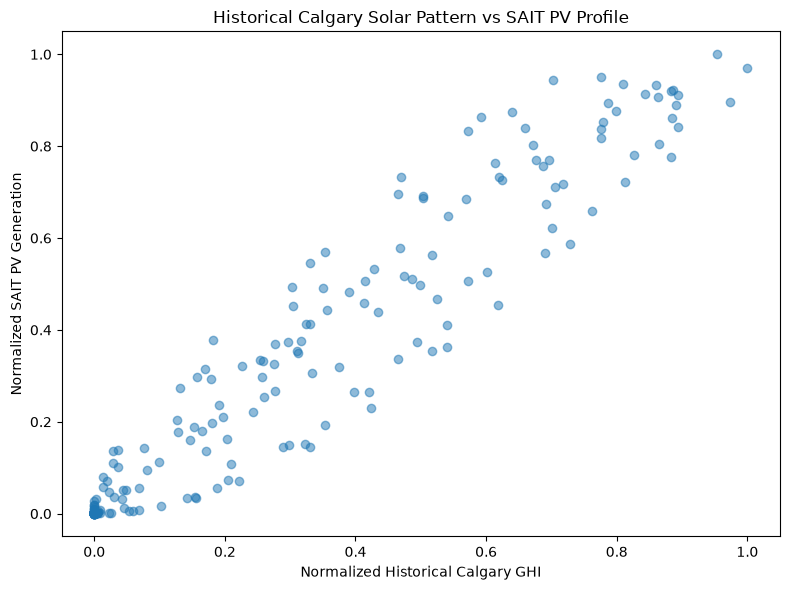

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(
    profile_comparison["ghi_normalized"],
    profile_comparison["pv_normalized"],
    alpha=0.5
)

plt.xlabel("Normalized Historical Calgary GHI")
plt.ylabel("Normalized SAIT PV Generation")
plt.title("Historical Calgary Solar Pattern vs SAIT PV Profile")

plt.tight_layout()
plt.show()

In [23]:
OUTPUT_DIR = DATA_DIR / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

coverage_summary.to_csv(
    OUTPUT_DIR / "d6_dataset_coverage_summary.csv",
    index=False
)

d6_status.to_csv(
    OUTPUT_DIR / "d6_validation_status.csv",
    index=False
)

profile_comparison.to_csv(
    OUTPUT_DIR / "d6_climatology_sait_profile_comparison.csv",
    index=False
)

print("D6 supporting outputs saved.")

D6 supporting outputs saved.


### Supporting SAIT Consistency Check

Because the supplied Calgary CWEEDS dataset ends in 2017 and usable SAIT solar observations begin in 2019, direct timestamp-aligned validation could not be performed.

As a supporting analysis, historical Calgary GHI was aggregated by month and hour and compared with the corresponding normalized SAIT PV generation profile. The resulting Pearson correlation was 0.9686, indicating a very strong similarity in seasonal and diurnal shape.

This result supports the physical consistency of the CWEEDS-based solar resource analysis with measured SAIT campus generation, but it is not reported as predictive model accuracy because the underlying observations are from different time periods.